In [147]:
# print("hello")

### Loading Data

In [148]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


train_df=pd.read_csv('fashion-mnist_train.csv')
test_df=pd.read_csv('fashion-mnist_test.csv')

#The first column is the label the rest are pixel values
y_train_full=train_df.iloc[:, 0].values
X_train_full=train_df.iloc[:, 1:].values

y_test_full=test_df.iloc[:, 0].values
X_test_full=test_df.iloc[:, 1:].values

print("Original Train shape:", X_train_full.shape)
print("Original Test shape:", X_test_full.shape)

Original Train shape: (60000, 784)
Original Test shape: (10000, 784)


### Filtering

In [149]:
# Select only classes 0, 1, and 2

train_filter = np.isin(y_train_full, [0, 1, 2])
test_filter = np.isin(y_test_full, [0, 1, 2])

X_train_sampled = X_train_full[train_filter]
y_train = y_train_full[train_filter].astype(float)

X_test_sampled = X_test_full[test_filter]
y_test  = y_test_full[test_filter].astype(float)

X_train = X_train_sampled / 255.0
X_test = X_test_sampled / 255.0

print("Filtered Train shape:", X_train.shape)
print("Filtered Test shape:", X_test.shape)

Filtered Train shape: (18000, 784)
Filtered Test shape: (3000, 784)


## PCA

In [150]:
no_train_observations=X_train.shape[0]

#Finding the Mean with explicit loops
mean=np.zeros((1,784))

for i in range(784):
    sum_val=0
    for j in range(no_train_observations):
        sum_val += X_train[j][i]
    mean[0][i]=sum_val / no_train_observations

#Centering the training data
X_c=X_train-mean

#Covariance matrix computation
sigma=(X_c.T @ X_c) / (no_train_observations-1)

#Finding eigenvalues and eigenvectors
eigenvalues,eigenvectors=np.linalg.eigh(sigma)

eig=[]
for i in range(784):
    eig.append((eigenvalues[i],eigenvectors[:,i]))

eig.sort(key=lambda x: x[0],reverse=True)

p=10
print("No. of components : ",p)

# Constructing the projection matrix U
U=eig[0][1].reshape(-1,1)

for i in range(1,p):
    new_col=eig[i][1].reshape(-1,1)
    U=np.hstack((U,new_col))

#Obtaining the projected centered matrices
X_train_pca=X_c @ U
X_test_pca=(X_test-mean) @ U

print("PCA Train shape:",X_train_pca.shape)
print("PCA Test  shape:",X_test_pca.shape)

No. of components :  10
PCA Train shape: (18000, 10)
PCA Test  shape: (3000, 10)


## Decision stump

In [151]:

def train_stump(X, y):
    
    n_samples, n_features=X.shape
    best_ssr=float('inf')
    best_feature=None
    best_threshold=None
    best_means=(0, 0) #(mean_left, mean_right)
    
    for j in range(n_features):
        # Sorting values in ascending order
        sort_idx=np.argsort(X[:, j])
        x_sorted=X[:, j][sort_idx]
        y_sorted=y[sort_idx]
        
        # Find unique values to determine candidate splits
        unique_vals, unique_idx=np.unique(x_sorted, return_index=True)
        
        if len(unique_vals)<= 1:
            continue
            
        #Split indices are just before the next unique value
        split_indices=unique_idx[1:]-1
        

        for split_idx in split_indices:
            
            # Divide data into left and right regions
            y_L=y_sorted[:split_idx + 1]
            y_R=y_sorted[split_idx + 1:]
            
            #mean response values
            mean_L=np.mean(y_L)
            mean_R=np.mean(y_R)
            
            # SSR=sum((y_i-y_L_mean)^2) + sum((y_i-y_R_mean)^2)
            ssr=np.sum((y_L-mean_L)**2) + np.sum((y_R-mean_R)**2)
            
            if ssr < best_ssr:
                best_ssr=ssr
                best_feature=j
                
                # Threshold is the midpoint between consecutive sorted values
                left_val=x_sorted[split_idx]
                right_val=x_sorted[split_idx + 1]
                best_threshold=(left_val + right_val) / 2.0
                
                # Prediction is the mean response value
                best_means=(mean_L, mean_R)

                
    return {'feature':best_feature,'threshold':best_threshold,'mean_left':best_means[0],'mean_right':best_means[1]}

def predict_stump(stump, X):
    preds=np.where(X[:, stump['feature']] <= stump['threshold'],stump['mean_left'], stump['mean_right'])
    return preds

### report

In [152]:
#Training single decision stump
h1=train_stump(X_train_pca, y_train)

print(f"Best Split Feature: {h1['feature']}, Threshold: {h1['threshold']:.4f}")
print(f"Left Mean: {h1['mean_left']:.4f}, Right Mean: {h1['mean_right']:.4f}")


y_test_pred_single=predict_stump(h1, X_test_pca)
test_mse_single=np.mean((y_test - y_test_pred_single)**2)

print(f"Test Set MSE (Single Stump): {test_mse_single:.4f}")

Best Split Feature: 2, Threshold: 1.5207
Left Mean: 1.3758, Right Mean: 0.1413
Test Set MSE (Single Stump): 0.3580


### Bagging and out of bag errors

In [153]:

np.random.seed(42)
n_samples=X_train_pca.shape[0]
n_models=5

bagged_stumps=[]
oob_mse_list=[]

print("Training 5 Bootstrap Bagged Stumps")
for i in range(n_models):
    #bootstrap dataset by sampling with replacement
    boot_indices=np.random.choice(n_samples,size=n_samples,replace=True)
    oob_indices=np.setdiff1d(np.arange(n_samples),boot_indices)
    
    X_boot,y_boot=X_train_pca[boot_indices],y_train[boot_indices]
    X_oob, y_oob =X_train_pca[oob_indices], y_train[oob_indices]
    
    #Train stump
    stump=train_stump(X_boot,y_boot)
    bagged_stumps.append(stump)
    
    #Compute OOB Error (MSE)
    y_oob_pred=predict_stump(stump,X_oob)
    oob_mse=np.mean((y_oob-y_oob_pred)**2)
    oob_mse_list.append(oob_mse)
    
    print(f"Model {i+1} trained. OOB MSE: {oob_mse:.4f}")

#Average OOB error across all models
print(f"\nAverage OOB Error (MSE): {np.mean(oob_mse_list):.4f}")

#Prediction is the average of predictions from all models
preds_list = []

for stump in bagged_stumps:
    prediction = predict_stump(stump, X_test_pca)
    preds_list.append(prediction)

all_test_preds = np.array(preds_list)
y_test_pred_bagged=np.mean(all_test_preds,axis=0)

test_mse_bagged=np.mean((y_test-y_test_pred_bagged)**2)
print(f"Test Set MSE (Bagging): {test_mse_bagged:.4f}")


#prediction on the full original training set
all_train_preds = np.array([predict_stump(stump, X_train_pca) for stump in bagged_stumps])
y_train_pred_bagged = np.mean(all_train_preds, axis=0)

#calculate train Set MSE using bagging
train_mse_bagged = np.mean((y_train - y_train_pred_bagged)**2)
print(f"Train Set MSE (Bagging): {train_mse_bagged:.4f}")

Training 5 Bootstrap Bagged Stumps
Model 1 trained. OOB MSE: 0.3526
Model 2 trained. OOB MSE: 0.3618
Model 3 trained. OOB MSE: 0.3433
Model 4 trained. OOB MSE: 0.3446
Model 5 trained. OOB MSE: 0.3545

Average OOB Error (MSE): 0.3514
Test Set MSE (Bagging): 0.3519
Train Set MSE (Bagging): 0.3389


## plotting

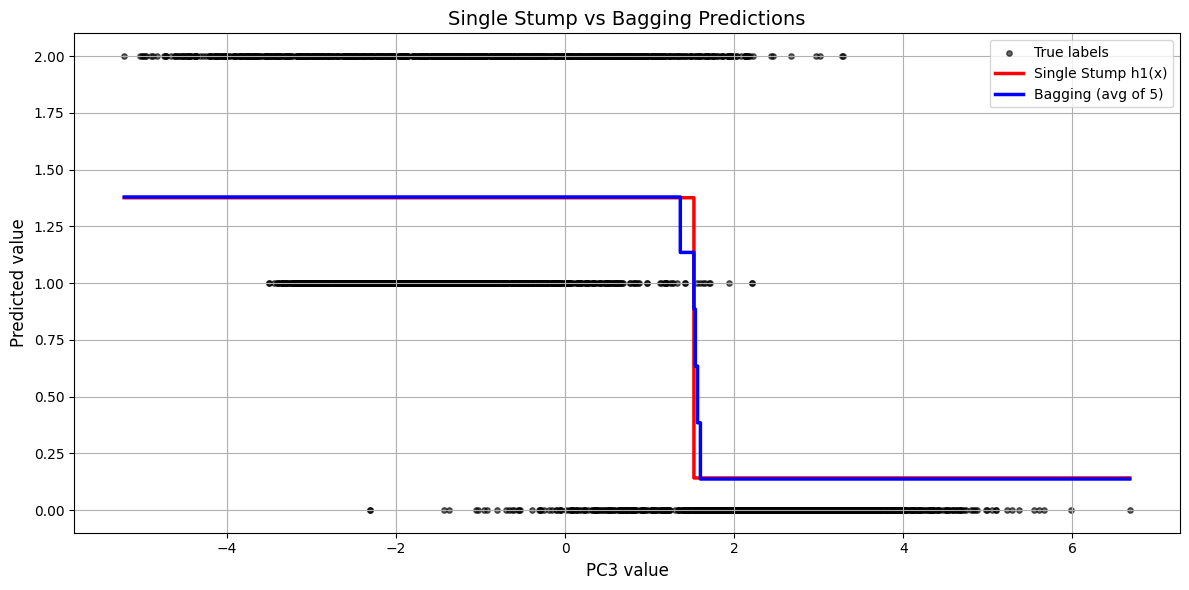

In [154]:
best_feat_idx=h1['feature'] 


feature_vals=X_test_pca[:,best_feat_idx]

# Sort everything based on that feature

sort_order=np.argsort(feature_vals)

x_sorted=feature_vals[sort_order]
y_true_sorted=y_test[sort_order]
y_single_sorted=y_test_pred_single[sort_order]
y_bagged_sorted=y_test_pred_bagged[sort_order]

#Create the plot
plt.figure(figsize=(12,6))

# Plot True Labels as a scatter plot
plt.scatter(x_sorted,y_true_sorted,color='black',s=15,alpha=0.6,label='True labels')

# Plot Single Stump predictions as a step function
plt.step(x_sorted,y_single_sorted,color='red',linewidth=2.5,where='post',label='Single Stump h1(x)')


plt.step(x_sorted,y_bagged_sorted,color='blue',linewidth=2.5,where='post',label='Bagging (avg of 5)')

plt.title('Single Stump vs Bagging Predictions',fontsize=14)

plt.xlabel(f'PC{best_feat_idx + 1} value',fontsize=12) 
plt.ylabel('Predicted value',fontsize=12)

#set the y axis ticks to show the decimal values clearly
plt.yticks(np.arange(0,2.25,0.25))

plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()

plt.show()